<a href="https://colab.research.google.com/github/EnasF/Applying-XAI-for-Demand-Forecasting-and-Pricing-Decision-in-Supply-Chain/blob/main/Capstone_Project_LSTM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM Demand Forecasting Across Three Samples

This notebook trains and evaluates LSTM on three samples: **Sample A**, **Sample B**, and **Sample C**.

The workflow includes:

1. Loading the three processed datasets.
2. Encoding categorical features.
3. Creating grouped 28-day sliding windows by `store_id` and `item_id`.
4. Training a separate LSTM model for each sample.
5. Evaluating RMSE, MAE, and R².
6. Comparing results across samples.

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load three processed samples
df_A = pd.read_csv(
    '/content/drive/MyDrive/Graduation Project Data/processed_data_A.csv',
    parse_dates=["date"]
)

df_B = pd.read_csv(
    '/content/drive/MyDrive/Graduation Project Data/processed_data_B.csv',
    parse_dates=["date"]
)

df_C = pd.read_csv(
    '/content/drive/MyDrive/Graduation Project Data/processed_data_C.csv',
    parse_dates=["date"]
)

samples = {
    "Sample_A": df_A,
    "Sample_B": df_B,
    "Sample_C": df_C
}

print("Sample A shape:", df_A.shape)
print("Sample B shape:", df_B.shape)
print("Sample C shape:", df_C.shape)

Mounted at /content/drive
Sample A shape: (737580, 49)
Sample B shape: (737580, 49)
Sample C shape: (737580, 49)


## 2. Encode Categorical Features

LSTM models require numeric inputs. This function converts categorical columns into integer codes while keeping the original columns unless `drop_original=True`.

In [ ]:
def encode_categorical_features(df, categorical_cols, drop_original=False):
    """
    Encode categorical columns using pandas category codes.
    """
    df = df.copy()
    mappings = {}

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype("category")
            df[col + "_code"] = df[col].cat.codes
            mappings[col] = dict(enumerate(df[col].cat.categories))

            if drop_original:
                df = df.drop(columns=[col])

    return df, mappings

## 3. Define Features, Target, and Group Columns

In [ ]:
# Target variable
target_col = "demand"

# Sliding window size
sequence_length = 28

# Group columns for separate time series
group_cols = ["store_id_code", "item_id_code"]

# Categorical columns to encode if they exist in the dataset
categorical_cols = [
    "store_id", "state_id", "item_id", "dept_id", "cat_id",
    "weekday", "event_name_1", "event_type_1",
    "event_name_2", "event_type_2", "month_year"
]

# Candidate feature columns
feature_cols = [
    "item_id_code", "dept_id_code", "cat_id_code",
    "store_id_code", "state_id_code",
    "wm_yr_wk", "weekday_code",
    "wday", "month", "year",

    "event_name_1_code", "event_type_1_code",
    "event_name_2_code", "event_type_2_code",

    "snap_CA", "snap_TX", "snap_WI",
    "sell_price",
    "sell_price_normalized",
    "price_change_flag",
    "price_change_direction",

    "month_year_code",

    "CAUR", "CPIAUCSL", "CPIUFDSL",
    "FEDFUNDS", "FEDFUNDS_diff",
    "TXUR", "UNRATE",
    "UMCSENT", "UMCSENT_diff",
    "WIUR",

    "demand_lag_7", "demand_lag_14", "demand_lag_28",
    "demand_rolling_mean_7", "demand_rolling_std_7",
    "demand_rolling_mean_14", "demand_rolling_std_14",
    "demand_rolling_mean_28", "demand_rolling_std_28",

    "price_lag_1", "price_lag_7",
    "price_rolling_mean_7", "price_rolling_std_7",
    "price_rolling_mean_28", "price_rolling_std_28"
]

## 4. Correct Grouped Sliding Window Function

This is the most important update. The previous simple sequence function used the full dataframe as one continuous series. That can accidentally create windows containing more than one item or store.

This function creates windows separately for each product-store time series.

In [ ]:
def create_grouped_sequences(
    df,
    feature_cols,
    target_col,
    group_cols,
    sequence_length=28,
    date_col="date"
):
    """
    Create LSTM sliding-window sequences separately for each store-item time series.

    This prevents mixing different products or stores inside the same 28-day window.

    Example:
    For each store_id + item_id:
        Day 1  to Day 28  -> predict Day 29
        Day 2  to Day 29  -> predict Day 30
        Day 3  to Day 30  -> predict Day 31
    """
    X_seq = []
    y_seq = []

    df = df.copy()
    df = df.sort_values(group_cols + [date_col]).reset_index(drop=True)

    for _, group in df.groupby(group_cols, observed=True):
        group = group.sort_values(date_col).reset_index(drop=True)

        if len(group) <= sequence_length:
            continue

        X_group = group[feature_cols].values
        y_group = group[target_col].values

        for i in range(sequence_length, len(group)):
            X_seq.append(X_group[i-sequence_length:i])
            y_seq.append(y_group[i])

    return np.array(X_seq), np.array(y_seq)

## 5. Build LSTM Model

In [ ]:
def build_lstm_model(input_shape):
    """
    Build LSTM model for demand forecasting.
    """
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),

        LSTM(64),
        Dropout(0.3),

        Dense(32, activation="relu"),
        Dropout(0.2),

        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0003,
            clipnorm=1.0
        ),
        loss=tf.keras.losses.Huber()
    )

    return model

## 6. Metric Function

In [ ]:
def calculate_regression_metrics(y_true, y_pred):
    """
    Calculate RMSE, MAE, and R2.
    """
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

## 7. Full LSTM Training Function

This function performs the full workflow:

1. Encode categorical features  
2. Sort data by group and date  
3. Split data using time-based split  
4. Scale features and target  
5. Create grouped 28-day sequences  
6. Train LSTM  
7. Evaluate on train, validation, and test sets

In [ ]:
def train_lstm_on_sample(
    df,
    sample_name,
    feature_cols,
    target_col="demand",
    categorical_cols=None,
    group_cols=None,
    sequence_length=28,
    date_col="date",
    epochs=100,
    batch_size=64
):
    print("\n" + "=" * 70)
    print(f"Running Grouped LSTM for {sample_name}")
    print("=" * 70)

    df = df.copy()

    # 1. Date handling
    df[date_col] = pd.to_datetime(df[date_col])

    # 2. Encode categorical features
    if categorical_cols is not None:
        df, mappings = encode_categorical_features(df, categorical_cols)
    else:
        mappings = {}

    # 3. Validate group columns
    if group_cols is None:
        group_cols = ["store_id_code", "item_id_code"]

    missing_group_cols = [col for col in group_cols if col not in df.columns]
    if missing_group_cols:
        raise ValueError(
            f"Missing group columns: {missing_group_cols}. "
            "Make sure store_id and item_id are encoded before sequence creation."
        )

    # 4. Keep only existing features
    used_features = [col for col in feature_cols if col in df.columns]
    if len(used_features) == 0:
        raise ValueError("No valid feature columns found in dataframe.")

    print(f"Number of used features: {len(used_features)}")

    # 5. Convert features and target to numeric
    for col in used_features + [target_col]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 6. Remove rows with missing values
    df = df.dropna(subset=used_features + [target_col] + group_cols + [date_col]).reset_index(drop=True)

    # 7. Sort for time-series structure
    df = df.sort_values(group_cols + [date_col]).reset_index(drop=True)

    # 8. Time-based split by unique dates
    unique_dates = np.array(sorted(df[date_col].unique()))
    train_end_idx = int(len(unique_dates) * 0.70)
    val_end_idx = int(len(unique_dates) * 0.90)

    train_dates = unique_dates[:train_end_idx]
    val_dates = unique_dates[train_end_idx:val_end_idx]
    test_dates = unique_dates[val_end_idx:]

    train_df = df[df[date_col].isin(train_dates)].copy()
    val_df = df[df[date_col].isin(val_dates)].copy()
    test_df = df[df[date_col].isin(test_dates)].copy()

    print("Train rows:", train_df.shape)
    print("Validation rows:", val_df.shape)
    print("Test rows:", test_df.shape)

    # 9. Scale features and target. Fit only on training set to avoid data leakage.
    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()

    train_df[used_features] = feature_scaler.fit_transform(train_df[used_features])
    val_df[used_features] = feature_scaler.transform(val_df[used_features])
    test_df[used_features] = feature_scaler.transform(test_df[used_features])

    train_df[[target_col]] = target_scaler.fit_transform(train_df[[target_col]])
    val_df[[target_col]] = target_scaler.transform(val_df[[target_col]])
    test_df[[target_col]] = target_scaler.transform(test_df[[target_col]])

    # 10. Create grouped 28-day sequences
    X_train, y_train = create_grouped_sequences(
        train_df, used_features, target_col, group_cols,
        sequence_length=sequence_length, date_col=date_col
    )
    X_val, y_val = create_grouped_sequences(
        val_df, used_features, target_col, group_cols,
        sequence_length=sequence_length, date_col=date_col
    )
    X_test, y_test = create_grouped_sequences(
        test_df, used_features, target_col, group_cols,
        sequence_length=sequence_length, date_col=date_col
    )

    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val:", X_val.shape, "y_val:", y_val.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise ValueError(
            "Not enough rows per item-store group to create sequences. "
            "Try reducing sequence_length or checking the date split."
        )

    # 11. Build model
    model = build_lstm_model(input_shape=(sequence_length, X_train.shape[2]))
    model.summary()

    # 12. Callbacks
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        min_delta=0.0001,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    # 13. Train model
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # 14. Plot loss
    plt.figure(figsize=(10, 6))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"LSTM Training Loss - {sample_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # 15. Predictions
    train_pred_scaled = model.predict(X_train)
    val_pred_scaled = model.predict(X_val)
    test_pred_scaled = model.predict(X_test)

    # 16. Inverse transform target and predictions
    y_train_actual = target_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
    y_val_actual = target_scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    train_pred = target_scaler.inverse_transform(train_pred_scaled).flatten()
    val_pred = target_scaler.inverse_transform(val_pred_scaled).flatten()
    test_pred = target_scaler.inverse_transform(test_pred_scaled).flatten()

    # Demand cannot be negative
    train_pred = np.clip(train_pred, 0, None)
    val_pred = np.clip(val_pred, 0, None)
    test_pred = np.clip(test_pred, 0, None)

    # 17. Evaluation
    train_metrics = calculate_regression_metrics(y_train_actual, train_pred)
    val_metrics = calculate_regression_metrics(y_val_actual, val_pred)
    test_metrics = calculate_regression_metrics(y_test_actual, test_pred)

    print(f"\n{sample_name} Train Metrics:")
    print(train_metrics)
    print(f"\n{sample_name} Validation Metrics:")
    print(val_metrics)
    print(f"\n{sample_name} Test Metrics:")
    print(test_metrics)

    return {
        "sample_name": sample_name,
        "model": model,
        "history": history,
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
        "used_features": used_features,
        "group_cols": group_cols,
        "mappings": mappings,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "y_test_actual": y_test_actual,
        "test_pred": test_pred
    }

## 8. Run LSTM on Sample A, B, and C

Make sure `df_A`, `df_B`, and `df_C` are already loaded before running this section.


Running Grouped LSTM for Sample A
Number of used features: 44
Train rows: (516040, 60)
Validation rows: (147440, 60)
Test rows: (74100, 60)
X_train: (505400, 28, 44) y_train: (505400,)
X_val: (136800, 28, 44) y_val: (136800,)
X_test: (63460, 28, 44) y_test: (63460,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 28, 128)        │        88,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,097 (547.25 KB)

 Trainable params: 140,097 (547.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 75s 9ms/step - loss: 4.7600e-05 - val_loss: 2.0885e-05 - learning_rate: 3.0000e-04
Epoch 2/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step - loss: 2.9058e-05 - val_loss: 2.0894e-05 - learning_rate: 3.0000e-04
Epoch 3/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 68s 9ms/step - loss: 2.8966e-05 - val_loss: 2.0890e-05 - learning_rate: 3.0000e-04
Epoch 4/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 68s 9ms/step - loss: 2.8961e-05 - val_loss: 2.0888e-05 - learning_rate: 3.0000e-04
Epoch 5/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 68s 9ms/step - loss: 2.8960e-05 - val_loss: 2.0889e-05 - learning_rate: 3.0000e-04
Epoch 6/100
7891/7897 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.8130e-05
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 68s 9ms/step - loss: 2.8956e-05 - val_loss: 2.0889e-05 - learning_rate: 3.0000e-04
Epoch 7/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step - loss: 2.8716e-05 - val_loss: 2.0816e-05 - learni

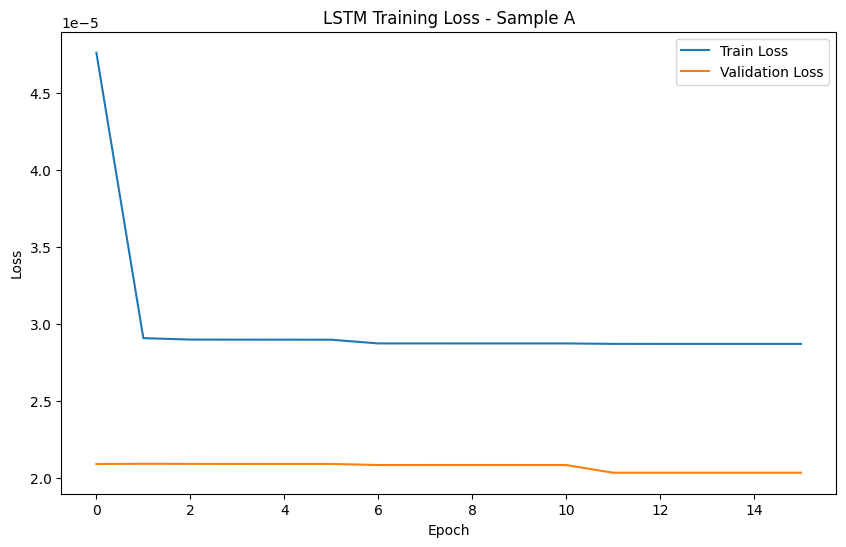

15794/15794 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step
4275/4275 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

Sample A Train Metrics:
{'RMSE': np.float64(3.459021437257376), 'MAE': 0.9874974880392431, 'R2': -0.07502514521487047}

Sample A Validation Metrics:
{'RMSE': np.float64(2.8178815317271857), 'MAE': 1.0667720477724154, 'R2': -0.14494825762968033}

Sample A Test Metrics:
{'RMSE': np.float64(3.111123842684074), 'MAE': 1.229383203492691, 'R2': -0.16443164174506641}


In [ ]:
lstm_results_A = train_lstm_on_sample(
    df=df_A,
    sample_name="Sample A",
    feature_cols=feature_cols,
    target_col=target_col,
    categorical_cols=categorical_cols,
    group_cols=group_cols,
    sequence_length=28,
    epochs=100,
    batch_size=64
)


Running Grouped LSTM for Sample B
Number of used features: 44
Train rows: (516040, 60)
Validation rows: (147440, 60)
Test rows: (74100, 60)
X_train: (505400, 28, 44) y_train: (505400,)
X_val: (136800, 28, 44) y_val: (136800,)
X_test: (63460, 28, 44) y_test: (63460,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 28, 128)        │        88,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,097 (547.25 KB)

 Trainable params: 140,097 (547.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 70s 9ms/step - loss: 3.4344e-04 - val_loss: 3.3390e-04 - learning_rate: 3.0000e-04
Epoch 2/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - loss: 1.9635e-04 - val_loss: 2.1122e-04 - learning_rate: 3.0000e-04
Epoch 3/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step - loss: 1.6374e-04 - val_loss: 1.7220e-04 - learning_rate: 3.0000e-04
Epoch 4/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - loss: 1.4504e-04 - val_loss: 1.7456e-04 - learning_rate: 3.0000e-04
Epoch 5/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step - loss: 1.4595e-04 - val_loss: 1.7546e-04 - learning_rate: 3.0000e-04
Epoch 6/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 68s 9ms/step - loss: 1.3715e-04 - val_loss: 1.5507e-04 - learning_rate: 3.0000e-04
Epoch 7/100
7894/7897 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6465e-04
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 68s 9ms/step - loss: 1.3108e-04 - val_loss: 1.4722e-04 - learni

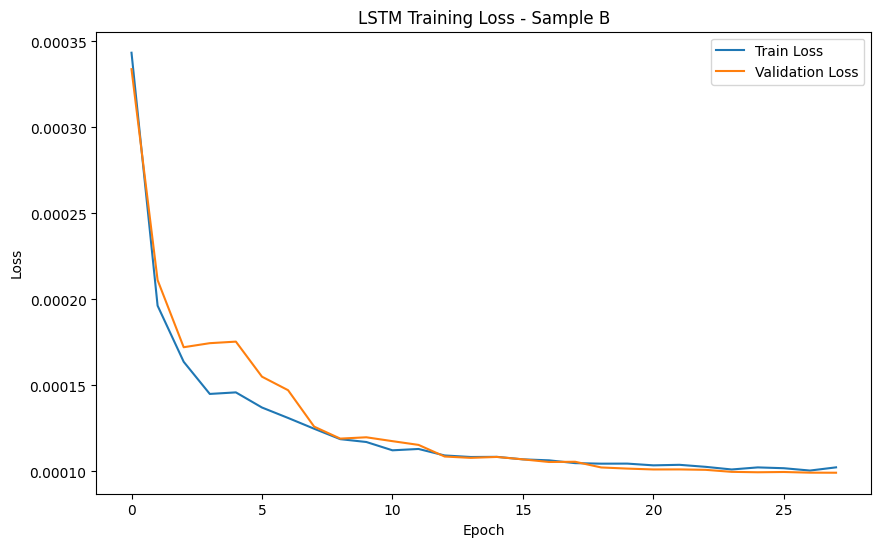

15794/15794 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step
4275/4275 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

Sample B Train Metrics:
{'RMSE': np.float64(1.8712432149897562), 'MAE': 0.70753020813205, 'R2': 0.7255574755448952}

Sample B Validation Metrics:
{'RMSE': np.float64(1.9299717711703495), 'MAE': 0.8463338112150971, 'R2': 0.6831065204254505}

Sample B Test Metrics:
{'RMSE': np.float64(2.01728176943026), 'MAE': 0.9502328773349887, 'R2': 0.6989064154493414}


In [ ]:
lstm_results_B = train_lstm_on_sample(
    df=df_B,
    sample_name="Sample B",
    feature_cols=feature_cols,
    target_col=target_col,
    categorical_cols=categorical_cols,
    group_cols=group_cols,
    sequence_length=28,
    epochs=100,
    batch_size=64
)


Running Grouped LSTM for Sample C
Number of used features: 44
Train rows: (516040, 60)
Validation rows: (147440, 60)
Test rows: (74100, 60)
X_train: (505400, 28, 44) y_train: (505400,)
X_val: (136800, 28, 44) y_val: (136800,)
X_test: (63460, 28, 44) y_test: (63460,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 28, 128)        │        88,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,097 (547.25 KB)

 Trainable params: 140,097 (547.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 77s 9ms/step - loss: 5.4208e-05 - val_loss: 4.1528e-05 - learning_rate: 3.0000e-04
Epoch 2/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 72s 9ms/step - loss: 3.4594e-05 - val_loss: 2.2588e-05 - learning_rate: 3.0000e-04
Epoch 3/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - loss: 2.3799e-05 - val_loss: 2.0161e-05 - learning_rate: 3.0000e-04
Epoch 4/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - loss: 2.2216e-05 - val_loss: 2.1303e-05 - learning_rate: 3.0000e-04
Epoch 5/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 72s 9ms/step - loss: 2.1487e-05 - val_loss: 2.0656e-05 - learning_rate: 3.0000e-04
Epoch 6/100
7895/7897 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.1911e-05
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 72s 9ms/step - loss: 2.0970e-05 - val_loss: 1.9480e-05 - learning_rate: 3.0000e-04
Epoch 7/100
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 72s 9ms/step - loss: 2.0762e-05 - val_loss: 1.7396e-05 - learni

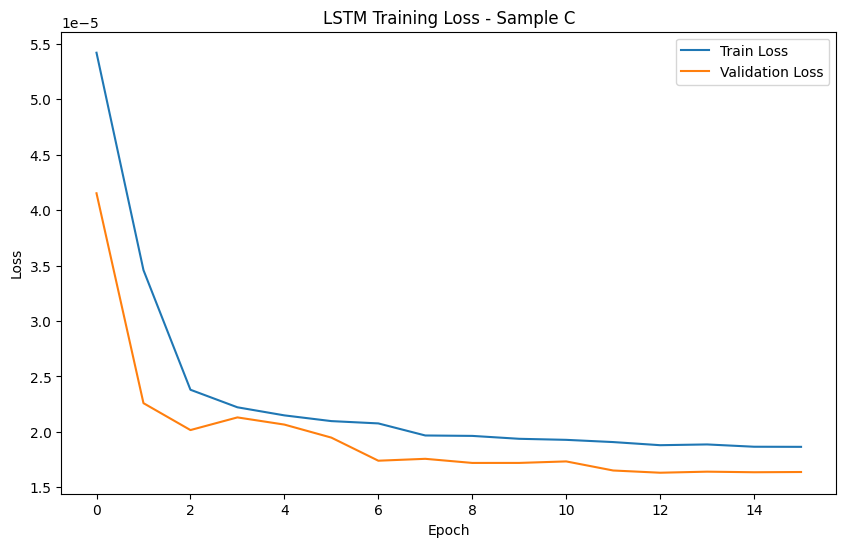

15794/15794 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step
4275/4275 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

Sample C Train Metrics:
{'RMSE': np.float64(2.760300400210663), 'MAE': 1.1199868694325776, 'R2': -0.02835988950856705}

Sample C Validation Metrics:
{'RMSE': np.float64(2.5699999841465084), 'MAE': 1.2004712230505215, 'R2': -0.10673282671370643}

Sample C Test Metrics:
{'RMSE': np.float64(2.7760278727843724), 'MAE': 1.3333886430850925, 'R2': -0.1389255965649856}


In [ ]:
lstm_results_C = train_lstm_on_sample(
    df=df_C,
    sample_name="Sample C",
    feature_cols=feature_cols,
    target_col=target_col,
    categorical_cols=categorical_cols,
    group_cols=group_cols,
    sequence_length=28,
    epochs=100,
    batch_size=64
)

## 9. Compare Test Results Across Samples

In [ ]:
performance_lstm = pd.DataFrame([
    {"Sample": "A", **lstm_results_A["test_metrics"]},
    {"Sample": "B", **lstm_results_B["test_metrics"]},
    {"Sample": "C", **lstm_results_C["test_metrics"]}
])

display(performance_lstm)

,Sample,RMSE,MAE,R2
0,A,3.111124,1.229383,-0.164432
1,B,2.017282,0.950233,0.698906
2,C,2.776028,1.333389,-0.138926


## 10. Plot Actual vs Predicted Demand

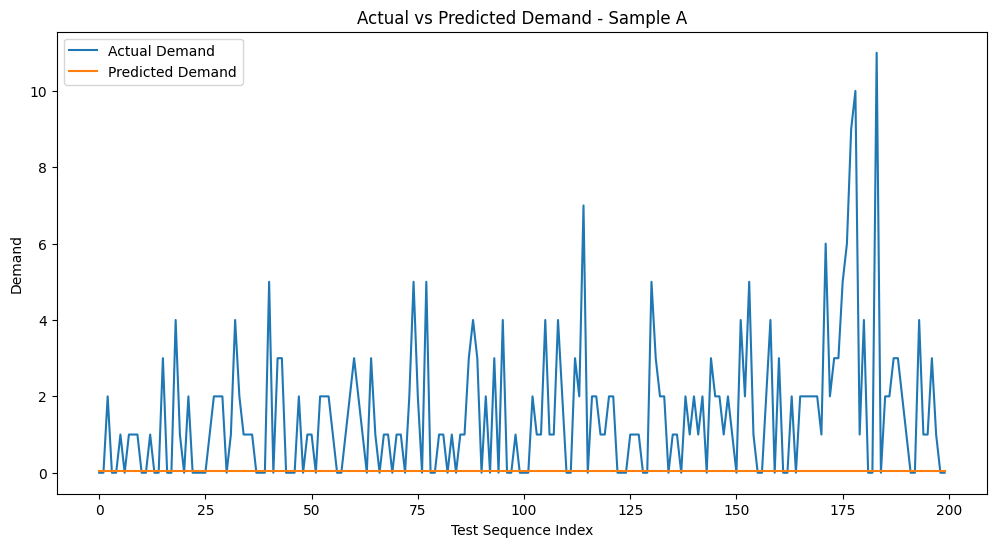

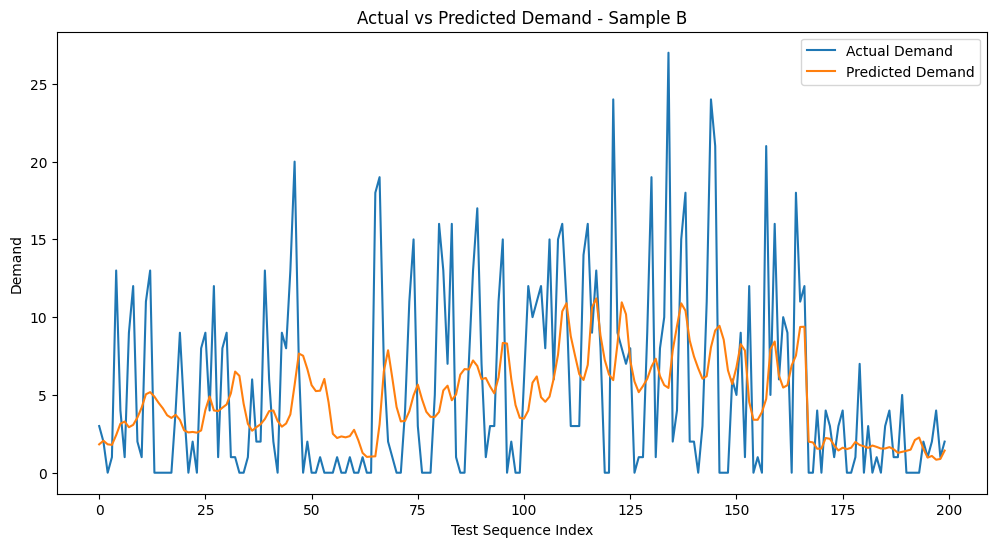

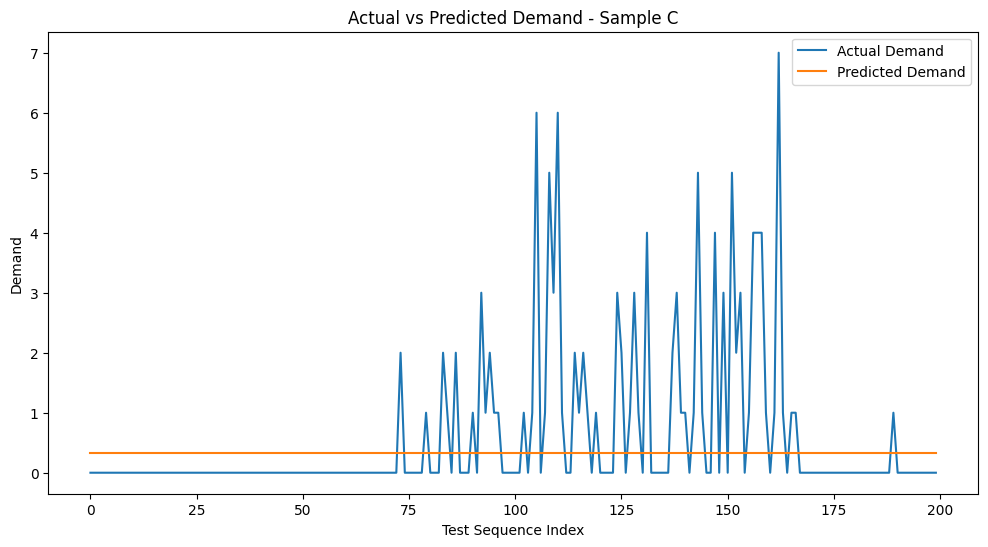

In [ ]:
def plot_actual_vs_predicted(result, n_points=200):
    sample_name = result["sample_name"]
    y_actual = result["y_test_actual"][:n_points]
    y_pred = result["test_pred"][:n_points]

    plt.figure(figsize=(12, 6))
    plt.plot(y_actual, label="Actual Demand")
    plt.plot(y_pred, label="Predicted Demand")
    plt.title(f"Actual vs Predicted Demand - {sample_name}")
    plt.xlabel("Test Sequence Index")
    plt.ylabel("Demand")
    plt.legend()
    plt.show()

plot_actual_vs_predicted(lstm_results_A)
plot_actual_vs_predicted(lstm_results_B)
plot_actual_vs_predicted(lstm_results_C)


> The LSTM model was trained using a grouped 28-day sliding window, where sequences were generated separately for each store-item time series. This prevented data leakage across different products and stores and ensured that the model learned temporal demand patterns within each individual series. The model was evaluated using RMSE, MAE, and R² on the test set. The results were compared across Samples A, B, and C to assess model stability and generalization across different stratified samples. Looks Like LSTM Faild to capture the all samples pattrens.